## Distribution 

This notebook explores the data distribution mainly on the categories , Labels (Y) that we would need model to know and predict ! 

In [1]:
import os 
import geopandas as gpd 

In [2]:
print(os.getcwd())

/Users/krschap/foss/landcoverclassification/notebooks


In [ ]:
data_path = os.path.join(os.getcwd(),'..','data','geojson','polygon_cleaned.geojson')
data = gpd.read_file(data_path)

In [5]:
data

,CODIGO,OBSERV,INSUMO,APOYO,ASIGNACION,Asignado,OAM,area,url_type,download_url,poly_id,image_uid,geometry
0,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,34429.374,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,0,img_0000_c4a77f3e,"MULTIPOLYGON (((-72.97056 10.61903, -72.97054 ..."
1,21,seasonal crops,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,6784.769,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1,img_0000_c4a77f3e,"MULTIPOLYGON (((-72.96914 10.61884, -72.96915 ..."
2,112,urban not continuous,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,12227.436,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,2,img_0000_c4a77f3e,"MULTIPOLYGON (((-72.96928 10.61948, -72.96931 ..."
3,231,clean pasture,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,19385.187,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,3,img_0000_c4a77f3e,"MULTIPOLYGON (((-72.97264 10.61976, -72.97273 ..."
4,313,fragmented forest,Villanueva-orthophoto,None,Sofia,None,https://map.openaerialmap.org/#/-72.9698181152...,5013.914,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,4,img_0000_c4a77f3e,"MULTIPOLYGON (((-72.96917 10.62053, -72.9691 1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1948,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,1528.937,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1948,img_0029_37df798b,"MULTIPOLYGON (((-75.123 3.80901, -75.12297 3.8..."
1949,333,Bare areas,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,0.026,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1949,img_0029_37df798b,"MULTIPOLYGON (((-75.12391 3.81075, -75.1239 3...."
1950,232,wooded pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,10536.989,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1950,img_0029_37df798b,"MULTIPOLYGON (((-75.12278 3.8104, -75.12282 3...."
1951,231,clean pasture,668c76331684770001c33863,None,None,Juan,https://map.openaerialmap.org/#/-75.1227307319...,5139.198,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,1951,img_0029_37df798b,"MULTIPOLYGON (((-75.12367 3.81079, -75.12357 3..."


### Observation 

As we can see there are 1953 rows , out of which 3 of them didn't have any labels so we cleaned them , now this are the no of observation that we would train our model on , Here X are 1953 

In [6]:
y_value_counts= data['OBSERV'].value_counts()

In [11]:
y_value_counts

OBSERV
building                        683
clean pasture                   320
dense forest                    155
Bare areas                      145
urban not continuous            142
weedy pasture                   128
wooded pasture                   64
permanent crops                  57
fragmented forest                56
seasonal crops                   42
highway                          33
rivers                           21
urban                            17
Open forest                      17
lakes                            14
Secondary vegetation             14
Open grassland                   13
Shrubland                        10
Sandy areas                       6
Burnt areas                       4
comercial or industrial area      4
canals                            3
Dense grassland                   3
forest                            1
Name: count, dtype: int64

## Observation on the data distribution 

We can observe that dataset is imbalanced however it doesn't mean that categories are not important , they are important , we need to be wise enough . Here we can see above there are some clasess which only have very few labels like forest , dense grassland , canals , commercial or industrial area ! I think < 10 might introduce noise and model might not have enough data to fit ! 

<Axes: title={'center': 'Distribution of Land Cover Classes'}, xlabel='OBSERV'>

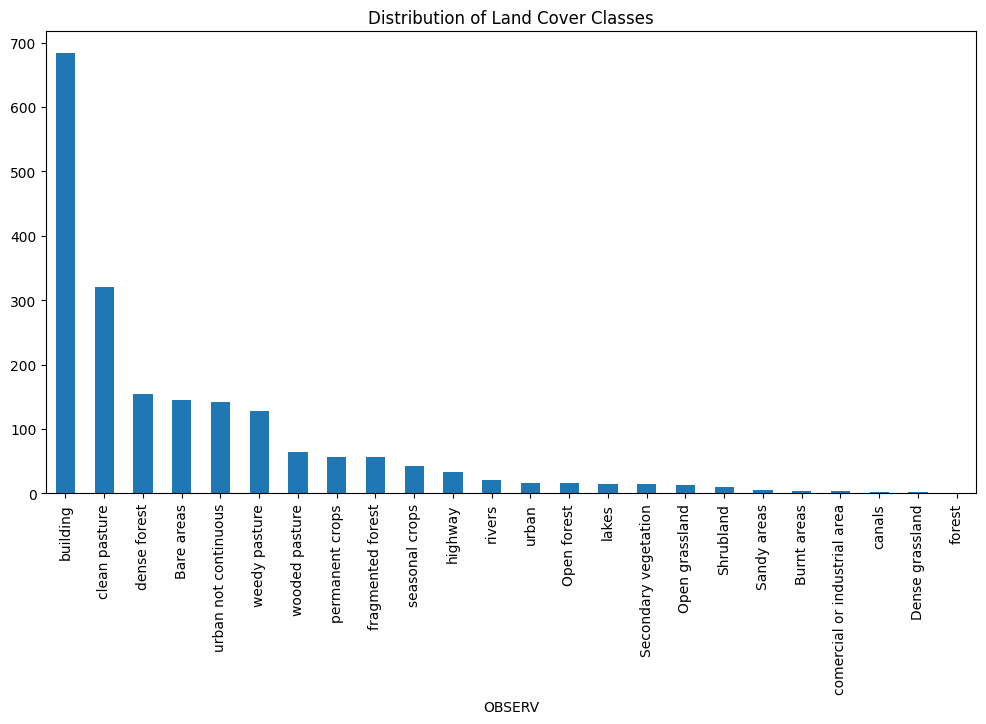

In [13]:
y_value_counts.plot(kind='bar', figsize=(12, 6), title='Distribution of Land Cover Classes')

In [9]:
data.url_type.value_counts()

url_type
oam       1421
gdrive     532
Name: count, dtype: int64

In [10]:
print(data.groupby('url_type')['image_uid'].nunique())


url_type
gdrive     7
oam       23
Name: image_uid, dtype: int64


### Observation : 
Based on the source distribution , we need to apply different preprocessing technique to download the data from OAM and from google drie and also get all of them together to make sure that they can be linked with the polygons we have ! 